In [1]:
from corporate_omissions.preprocessing.empirical_preprocessing import EmpiricalPreprocessor

import pandas as pd

In [2]:
from pathlib import Path

SAMPLE_PATH =  Path("/Users/giulia/Documents/GitHub/corporate-omissions/data/processed")

in_folder = SAMPLE_PATH / "panel_merged.parquet"

df = pd.read_parquet(
    in_folder,
    engine="pyarrow"   # explicit = reproducible
)

In [3]:
from corporate_omissions.data import preprocess_panel, PanelPreprocessConfig

# Disclosed/estimated split + co2_bool, applied here (not at merge) so the
# narrow/broad spec is a config flip on the same panel_merged.
# Main spec = "narrow" (exact only); robustness = "broad".

DEFINITION = "broad"
df = preprocess_panel(df, config=PanelPreprocessConfig(disclosed_definition=DEFINITION))
df.shape

(69746, 26)

In [4]:
REQUIRED_COLS = [
    "gvkey",
    "exchg",
    "year",
    "at",
    "gsector",
    "gind", 
    "gdp",
    "co2_bool",
    "sc1_disclosed", 
    "sc1_estimated", 
    "revt", 
    "wti_crude", 
    "ppi_petroleum", 
    "sc1_disclosure", 
    'mkvalt', 'sc1', 'int_sc1',
    "ppegt"
]

pp = EmpiricalPreprocessor(
    required_columns=REQUIRED_COLS,
    default_vars_to_winsorize=["at"]
)


out = pp.fix_df_empirical(
    df,
    year_subsample=2012,
    plot_bool=True,
    create_green_sector=False
)

out['raw'].shape

[EmpiricalPreprocessor] Data size (pre-filter): 69,746 rows
[EmpiricalPreprocessor] Data size (year >= 2012): 59,996 rows
[EmpiricalPreprocessor] Data size (after outlier removal): 58,796 rows
[EmpiricalPreprocessor] Plot skipped: no emissions column found.


(58796, 17)

In [5]:
from corporate_omissions.visualization.summary_tables import *
from pathlib import Path

OUT = Path("../data/outputs/tables")
OUT.mkdir(parents=True, exist_ok=True)

table1 = make_table1_summary(out['raw'], definition=DEFINITION)
table2 = make_table2_disclosure_types(out['raw'], year=2023, definition=DEFINITION)
table3 = make_table3_summary(out['raw'], wide=True, definition=DEFINITION)


(OUT / "table1_summary.tex").write_text(
    to_latex_table(
        table1,
        caption="Summary statistics by year.",
        label="tab:summary_year",
    )
)

(OUT / "table2_disclosure_types.tex").write_text(
    to_latex_table(
        table2,
        caption="Breakdown of disclosure types in Trucost data.",
        label="tab:disclosure_types",
    )
)

(OUT / "table3_summary_by_status.tex").write_text(
    to_latex_table(
        table3,
        caption="Summary statistics by year and emissions disclosure status.",
        label="tab:summary_year_status",
    )
)

1149

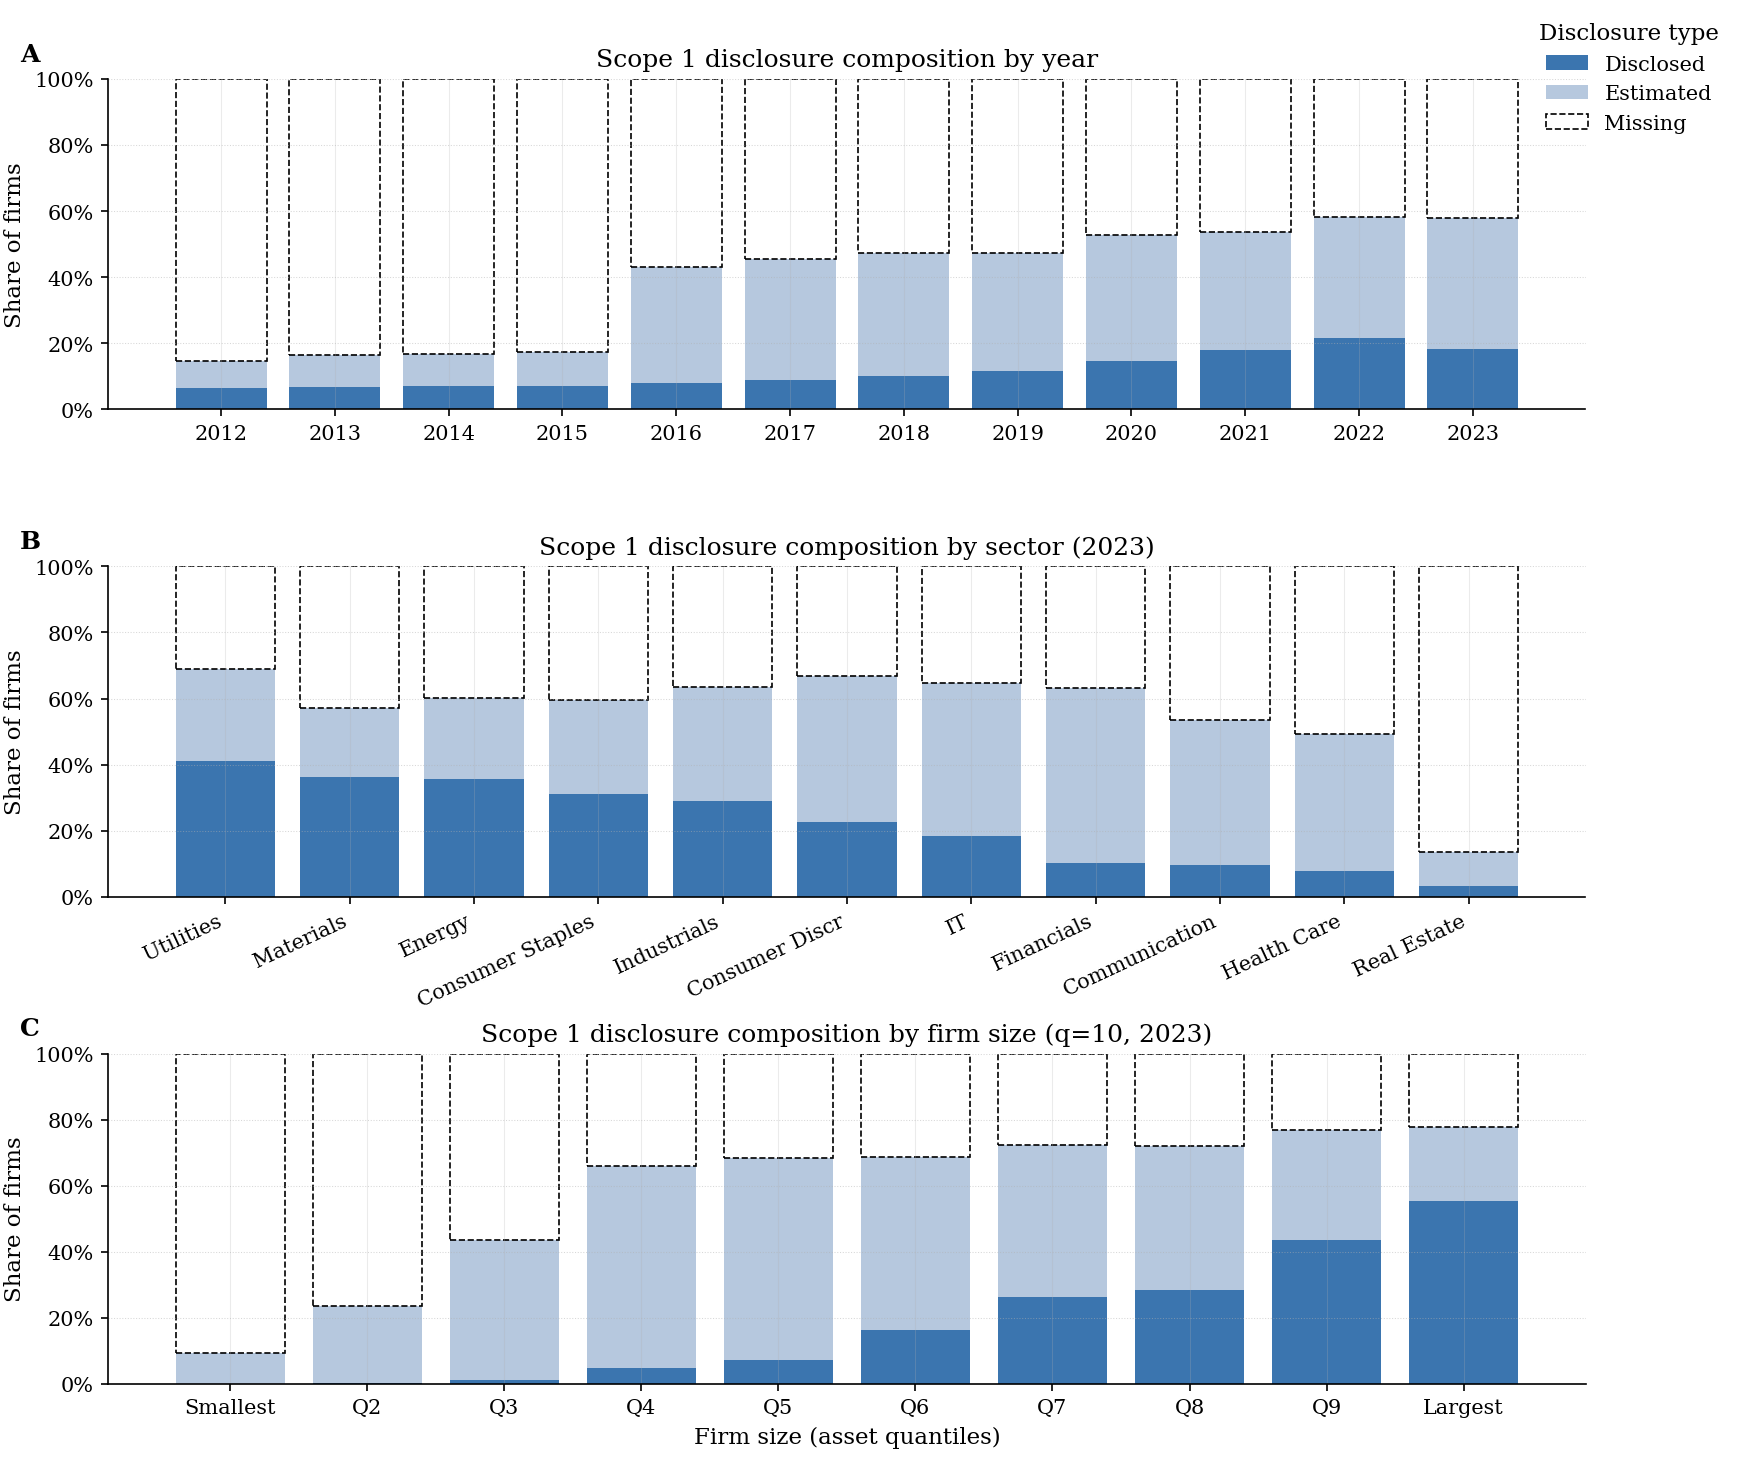

In [6]:
from pathlib import Path
from corporate_omissions.visualization.disclosure_graph import plot_scope1_disclosure_pct

OUT = Path("../data/outputs/figures")
OUT.mkdir(parents=True, exist_ok=True)

fig = plot_scope1_disclosure_pct(out['raw'].reset_index(), start_year=2012, sub_year=2023, figsize=(12,10))
fig.savefig(OUT / "fig1_disclosure.pdf", bbox_inches="tight")

In [7]:
out['raw'][['mkvalt', 'sc1', 'int_sc1','ppegt']].describe()

,mkvalt,sc1,int_sc1,ppegt
count,4.778900e+04,2.335000e+04,23350.000000,50119.00000
mean,6.403582e+03,1.146314e+06,161.661833,3473.77400
std,2.686597e+04,7.062450e+06,655.250259,14550.78581
min,0.000000e+00,0.000000e+00,0.000000,0.00000
25%,1.677801e+02,1.227616e+03,3.273000,16.54750
50%,8.069654e+02,1.231282e+04,12.096209,173.04900
75%,3.405191e+03,9.949624e+04,27.028000,1308.33400
max,1.516025e+06,1.850494e+08,14227.623824,349181.00000


In [8]:
from corporate_omissions.utils.paths import processed_dir

out_all = out["all"].reset_index()  # <- this is the DataFrame
out_all.drop(columns=["sc1_disclosure", "mkvalt", "sc1", "int_sc1"], inplace=True)

OUT_PROCESSED = Path("../data/processed")
OUT_PROCESSED.mkdir(parents=True, exist_ok=True)

out_path = OUT_PROCESSED / "all_empiricals.parquet"

out_all.to_parquet(
    out_path,
    engine="pyarrow",
    index=False
)

out_path

PosixPath('../data/processed/all_empiricals.parquet')